   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   s

/tmp/ipykernel_13291/2272929518.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean(), inplace=True)
/tmp/ipykernel_13291/2272929518.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

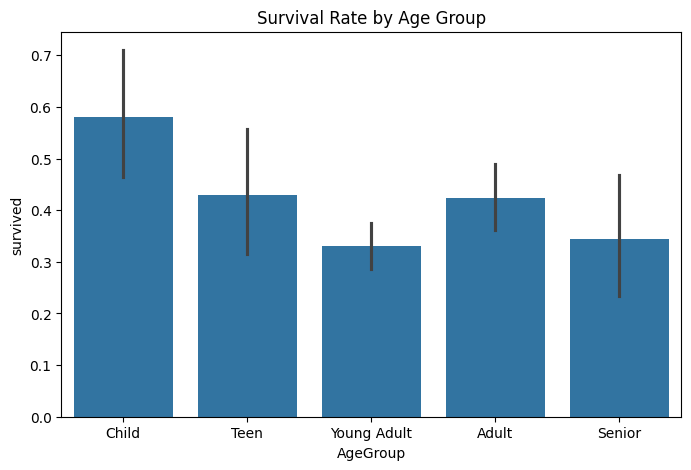


Survival Rate by Embarkation Port
embarked
C    0.553571
Q    0.389610
S    0.339009
Name: survived, dtype: float64


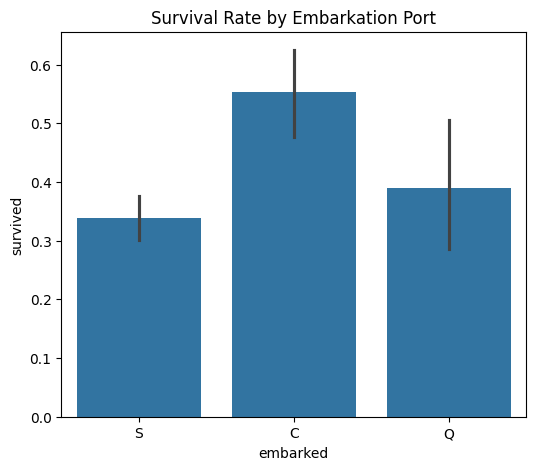


Survival Rate by Family Size
FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: survived, dtype: float64


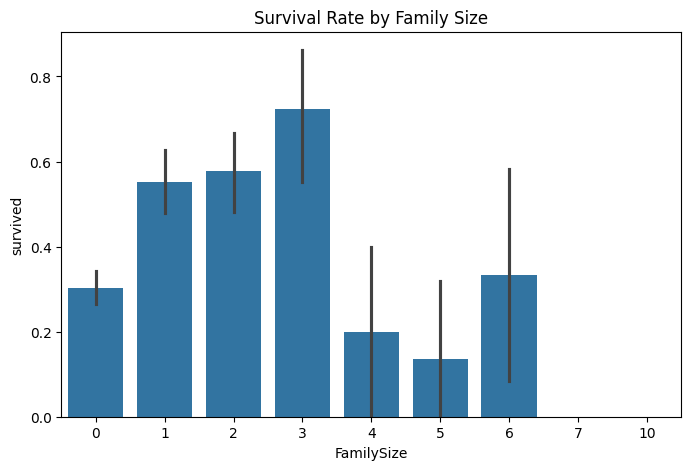

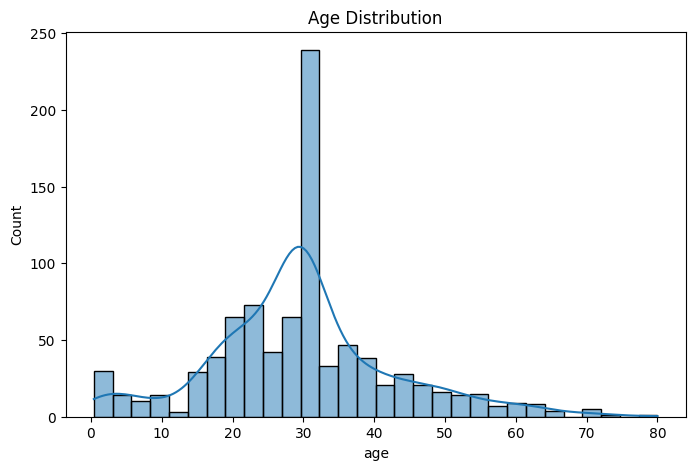

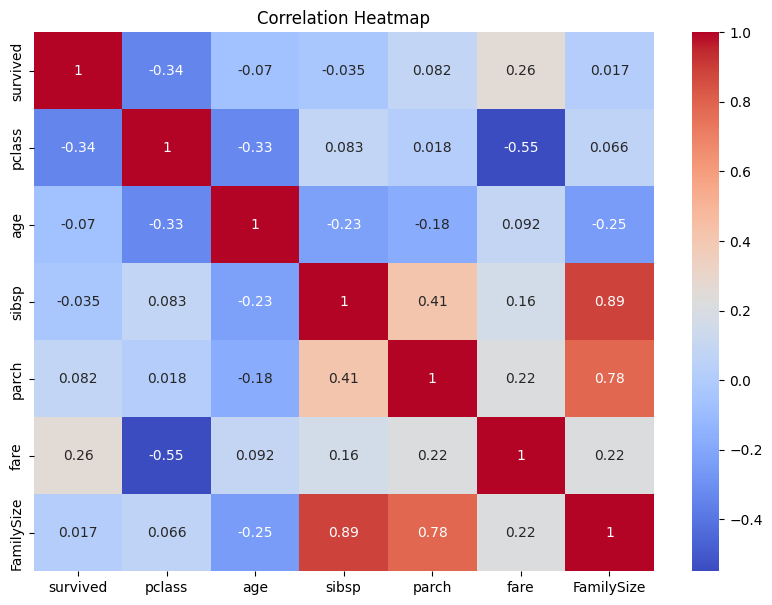


===== Insights =====
1. Missing Age values filled with Mean.
2. Missing Embarked values filled with Mode.
3. Deck column removed.
4. Created AgeGroup feature.
5. Created FamilySize feature.
6. Analyzed survival by Age Group, Embarkation Port and Family Size.
7. Generated Histogram, Heatmap and Bar Charts.

Task 3 Completed Successfully!


In [2]:
# ==========================
# Titanic Mini EDA - Task 3
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset directly from seaborn
df = sns.load_dataset("titanic")

# Display first five rows
print(df.head())

# Dataset information
print("\nDataset Information:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Data Cleaning
# -----------------------------

# Fill missing Age values with Mean
df["age"].fillna(df["age"].mean(), inplace=True)

# Fill missing Embarked values with Mode
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

# Drop Cabin column
df.drop(columns=["deck"], inplace=True)

# -----------------------------
# Feature Engineering
# -----------------------------

# Create Age Groups
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[0,12,18,30,50,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

# Create Family Size
df["FamilySize"] = df["sibsp"] + df["parch"]

# -----------------------------
# Survival by Age Group
# -----------------------------

print("\nSurvival Rate by Age Group")
print(df.groupby("AgeGroup")["survived"].mean())

plt.figure(figsize=(8,5))
sns.barplot(x="AgeGroup", y="survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

# -----------------------------
# Survival by Embarkation Port
# -----------------------------

print("\nSurvival Rate by Embarkation Port")
print(df.groupby("embarked")["survived"].mean())

plt.figure(figsize=(6,5))
sns.barplot(x="embarked", y="survived", data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()

# -----------------------------
# Survival by Family Size
# -----------------------------

print("\nSurvival Rate by Family Size")
print(df.groupby("FamilySize")["survived"].mean())

plt.figure(figsize=(8,5))
sns.barplot(x="FamilySize", y="survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

# -----------------------------
# Age Distribution
# -----------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# -----------------------------
# Correlation Heatmap
# -----------------------------

plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Insights
# -----------------------------

print("\n===== Insights =====")
print("1. Missing Age values filled with Mean.")
print("2. Missing Embarked values filled with Mode.")
print("3. Deck column removed.")
print("4. Created AgeGroup feature.")
print("5. Created FamilySize feature.")
print("6. Analyzed survival by Age Group, Embarkation Port and Family Size.")
print("7. Generated Histogram, Heatmap and Bar Charts.")

print("\nTask 3 Completed Successfully!")